# Keras TF 2.0 - Classification Task
## Breast Cancer Wisconsin Dataset
Binary Classification: Malignant (1) vs Benign (0)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

## Load Data

In [2]:
cancer = load_breast_cancer()
df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df['benign_0__mal_1'] = cancer['target']
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [4]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
benign_0__mal_1            0
dtype: int64

## EDA

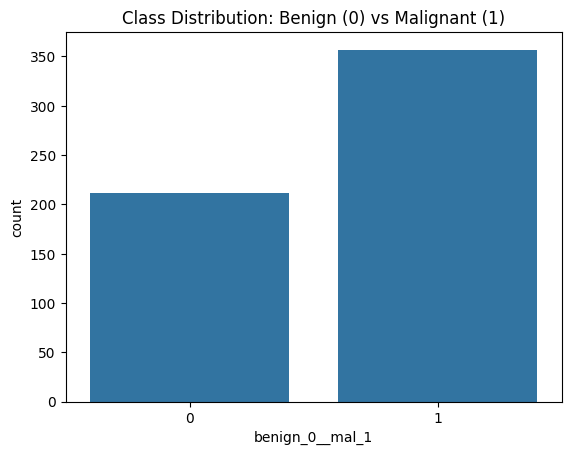

In [5]:
# Class distribution
sns.countplot(x='benign_0__mal_1', data=df)
plt.title('Class Distribution: Benign (0) vs Malignant (1)')
plt.show()

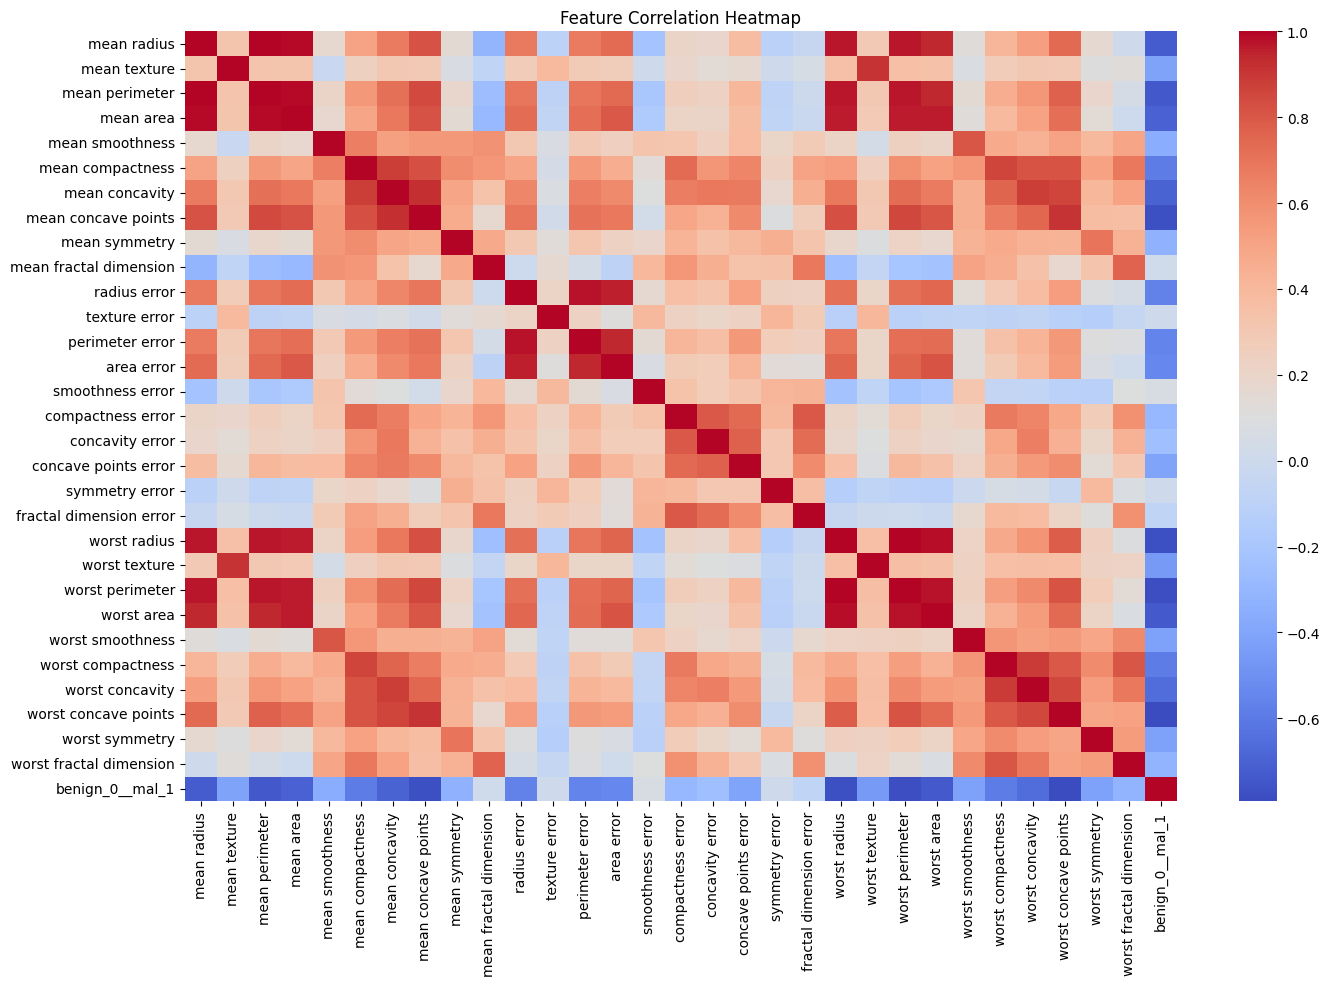

In [6]:
# Correlation heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

C:\Users\Huawei\AppData\Local\Temp\ipykernel_29648\3363326494.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='benign_0__mal_1', y='mean radius', data=df, palette='Set2')


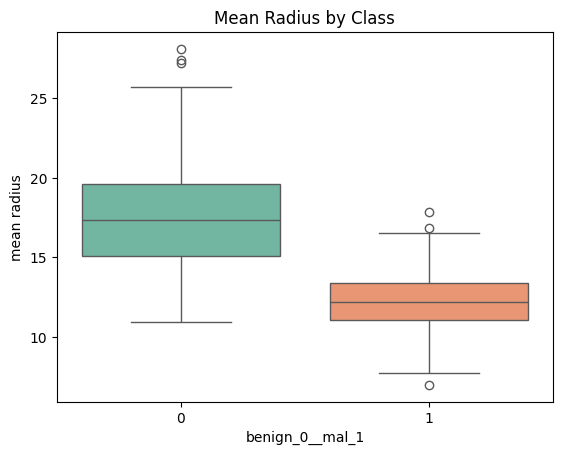

In [7]:
# Distribution of mean radius by class
sns.boxplot(x='benign_0__mal_1', y='mean radius', data=df, palette='Set2')
plt.title('Mean Radius by Class')
plt.show()

## Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('benign_0__mal_1', axis=1)
y = df['benign_0__mal_1']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=101
)

print(f'Train size: {X_train.shape}')
print(f'Test size:  {X_test.shape}')

Train size: (426, 30)
Test size:  (143, 30)


## Scaling Data

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test  = scaler.transform(X_test)

## Creating the Model

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Example One: Too many epochs (Overfitting)

In [11]:
model = Sequential()
model.add(Dense(30, activation='relu'))
model.add(Dense(15, activation='relu'))
model.add(Dense(1,  activation='sigmoid'))  # binary output

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train,
          epochs=600,
          validation_data=(X_test, y_test),
          verbose=0)

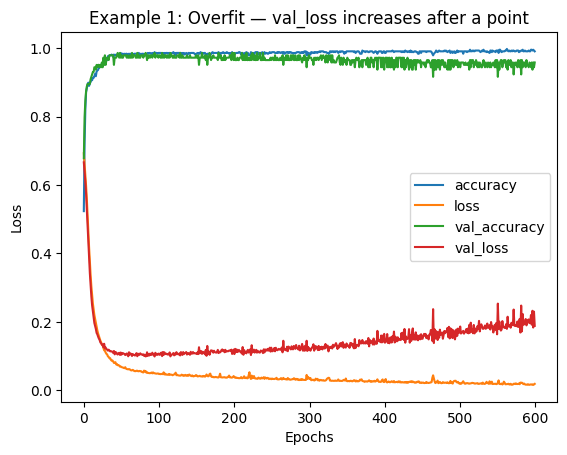

In [12]:
model_loss = pd.DataFrame(model.history.history)
model_loss.plot()
plt.title('Example 1: Overfit — val_loss increases after a point')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

### Example Two: Early Stopping

In [13]:
model2 = Sequential()
model2.add(Dense(30, activation='relu'))
model2.add(Dense(15, activation='relu'))
model2.add(Dense(1,  activation='sigmoid'))

model2.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',
                           mode='min',
                           patience=25,
                           verbose=1)

model2.fit(X_train, y_train,
           epochs=600,
           validation_data=(X_test, y_test),
           callbacks=[early_stop],
           verbose=0)

Epoch 78: early stopping


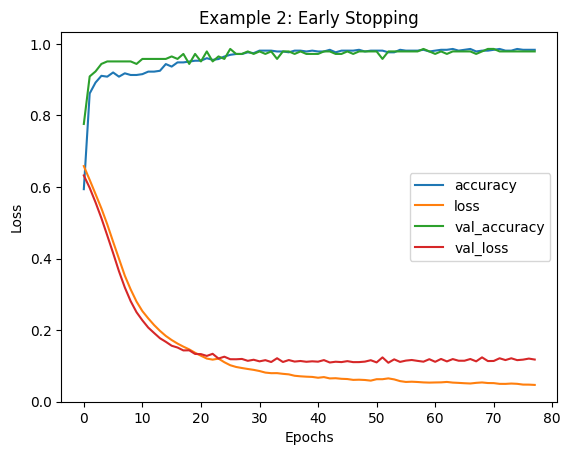

In [14]:
model_loss2 = pd.DataFrame(model2.history.history)
model_loss2.plot()
plt.title('Example 2: Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

### Example Three: Dropout Layers

In [15]:
model3 = Sequential()
model3.add(Dense(30, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(15, activation='relu'))
model3.add(Dropout(0.5))
model3.add(Dense(1,  activation='sigmoid'))

model3.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss',
                           mode='min',
                           patience=25,
                           verbose=1)

model3.fit(X_train, y_train,
           epochs=600,
           validation_data=(X_test, y_test),
           callbacks=[early_stop],
           verbose=0)

Epoch 115: early stopping


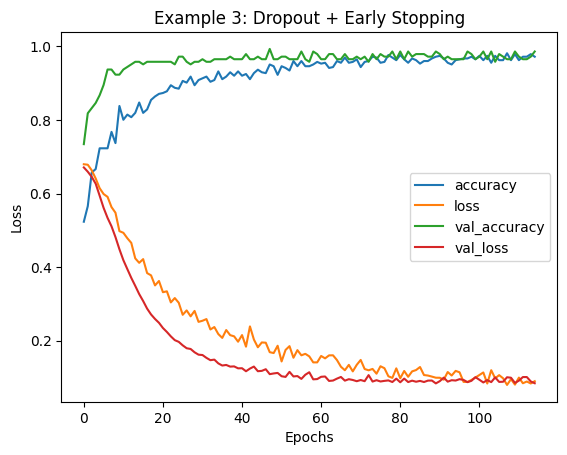

In [16]:
model_loss3 = pd.DataFrame(model3.history.history)
model_loss3.plot()
plt.title('Example 3: Dropout + Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

## Model Evaluation

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

# Use the best model (model3 with Dropout + EarlyStopping)
predictions = (model3.predict(X_test) > 0.5).astype(int)

print('=== Confusion Matrix ===')
print(confusion_matrix(y_test, predictions))
print()
print('=== Classification Report ===')
print(classification_report(y_test, predictions))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
=== Confusion Matrix ===
[[54  1]
 [ 1 87]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        55
           1       0.99      0.99      0.99        88

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



## Save Model & Scaler

In [21]:
import pickle
with open('scaler_weights.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("Saved scaler")

Saved scaler


In [22]:
model3.save('model_weights.keras')
print("Saved model3 — Accuracy 99%")

Saved model3 — Accuracy 99%
